In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from scipy.stats import multivariate_normal as mvn
from sklearn.mixture import GaussianMixture

In [4]:
def calculate_posterior(px, pi):
    """
    
    """
    weighted_px = px * pi  # broadcasting pi over rows of px

    # Denominator: sum over components for each data point i
    denom = weighted_px.sum(axis=1)  # shape (n,)

    # Posterior (responsibilities), shape (n, K)
    gamma = weighted_px / denom[:, np.newaxis]
    return gamma

In [5]:
# Load the iris dataset
iris = sns.load_dataset('iris')

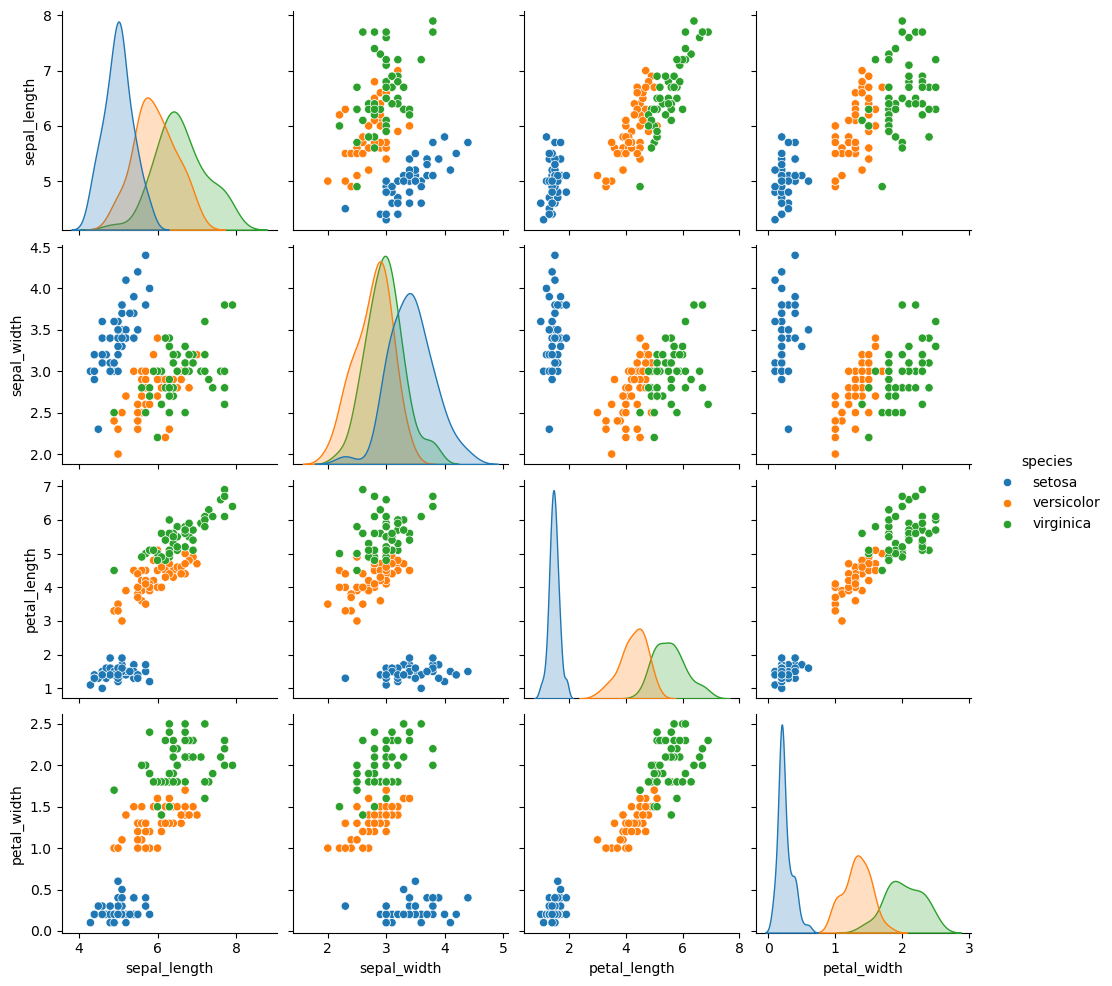

In [6]:
sns.pairplot(iris, hue='species')

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

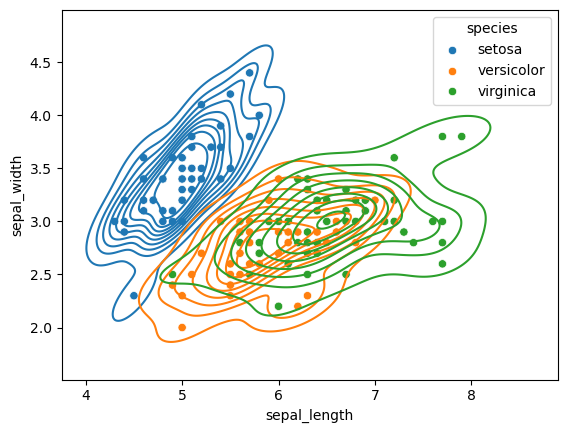

In [7]:
sns.kdeplot(data=iris,
            x='sepal_length',
            y='sepal_width',
            hue='species',
            thresh=0.05,
            levels=10,cmap='mako')
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width',hue='species',)

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='sepal_length', ylabel='petal_length'>

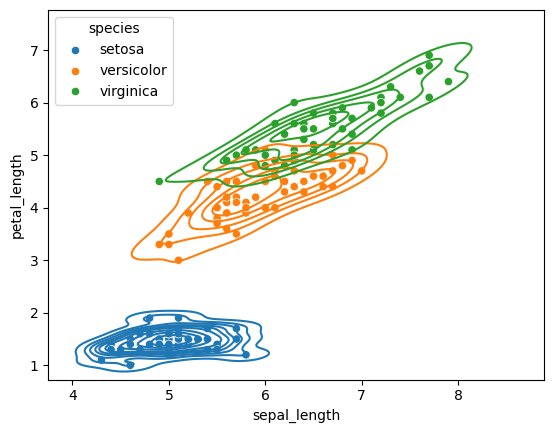

In [8]:
sns.kdeplot(data=iris,
            x='sepal_length',
            y='petal_length',
            hue='species',
            thresh=0.05,
            levels=10,cmap='mako')
sns.scatterplot(data=iris, x='sepal_length', y='petal_length',hue='species',)

In [9]:
from sklearn.mixture import GaussianMixture

In [10]:
# For multivariate data (e.g., eruptions and waiting)
gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(iris.iloc[:,:4])

GaussianMixture(n_components=3, random_state=0)

In [11]:
# Accessing the parameters
means = gmm.means_
covariances = gmm.covariances_
weights = gmm.weights_

print("Means:\n", means)
print("\nCovariances:\n", covariances)
print("\nMixing Proportions:\n", weights)

Means:
 [[5.9170732  2.77804839 4.20540364 1.29848217]
 [5.006      3.428      1.462      0.246     ]
 [6.54639415 2.94946365 5.48364578 1.98726565]]

Covariances:
 [[[0.2755171  0.09662295 0.18547072 0.05478901]
  [0.09662295 0.09255152 0.09103431 0.04299899]
  [0.18547072 0.09103431 0.20235849 0.06171383]
  [0.05478901 0.04299899 0.06171383 0.03233775]]

 [[0.121765   0.097232   0.016028   0.010124  ]
  [0.097232   0.140817   0.011464   0.009112  ]
  [0.016028   0.011464   0.029557   0.005948  ]
  [0.010124   0.009112   0.005948   0.010885  ]]

 [[0.38744093 0.09223276 0.30244302 0.06087397]
  [0.09223276 0.11040914 0.08385112 0.05574334]
  [0.30244302 0.08385112 0.32589574 0.07276776]
  [0.06087397 0.05574334 0.07276776 0.08484505]]]

Mixing Proportions:
 [0.30127092 0.33333333 0.36539575]


In [12]:
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [104]:
### Initialize


# Extract the 2D data (eruptions and waiting).
X = iris.iloc[:,:4].to_numpy()

mu1_hat = np.array(list(iris.iloc[:,:4].sample(1).iloc[0]))
mu2_hat = np.array(list(iris.iloc[:,:4].sample(1).iloc[0]))
mu3_hat = np.array(list(iris.iloc[:,:4].sample(1).iloc[0]))

# Initialize two covariance matrices as identity for simplicity.
Sigma1_hat = np.eye(X.shape[1])
Sigma2_hat = np.eye(X.shape[1])
Sigma3_hat = np.eye(X.shape[1])

# Mixing proportions (still scalars).
pi1_hat = 1/3
pi2_hat = 1/3
pi3_hat = 1/3

In [105]:
epoch_log_likelihood = {}

for i in range(100):

    px_class1 = [mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(xi) for xi in X]
    px_class2 = [mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(xi) for xi in X]
    px_class3 = [mvn(mean=mu3_hat, cov=Sigma3_hat).pdf(xi) for xi in X]

    px_class1 = np.array(px_class1)  # convert list to array
    px_class2 = np.array(px_class2)
    px_class3 = np.array(px_class3)   

    log_likelihood = np.sum(
    np.log( ( 
                pi1_hat * px_class1) + (pi2_hat * px_class2) + (pi3_hat * px_class3) 
            )
        )

    epoch_log_likelihood[i] = log_likelihood

    px = np.column_stack([px_class1, px_class2, px_class3])
    # Now px.shape == (n, 3)

    pi = np.array([pi1_hat, pi2_hat, pi3_hat])   # shape (3,)

    posteriors = calculate_posterior(px, pi)

    ## Maximization step

    ### Cluster 1
    posteriors_class1 = posteriors[:,0]

    # 1) Mean
    N1 = posteriors_class1.sum()
    mu1_hat = (X * posteriors_class1[:, None]).sum(axis=0) / N1

    # 2) Covariance
    diff1 = X - mu1_hat
    Sigma1_hat = (posteriors_class1[:, None] * diff1).T @ diff1 / N1
    ############################################################################################################

    ### Cluster 2
    posteriors_class2 = posteriors[:,1]

    # 1) Mean
    N2 = posteriors_class2.sum()
    mu2_hat = (X * posteriors_class2[:, None]).sum(axis=0) / N2

    # 2) Covariance
    diff2 = X - mu2_hat
    Sigma2_hat = (posteriors_class2[:, None] * diff2).T @ diff2 / N2
    ############################################################################################################

    ### Cluster 3
    posteriors_class3 = posteriors[:,2]

    # 1) Mean
    N3 = posteriors_class3.sum()
    mu3_hat = (X * posteriors_class3[:, None]).sum(axis=0) / N3

    # 2) Covariance
    diff3 = X - mu3_hat
    Sigma3_hat = (posteriors_class3[:, None] * diff3).T @ diff3 / N3
    ############################################################################################################

    pi1_hat = sum(posteriors_class1) / len(X)
    pi2_hat = sum(posteriors_class2) / len(X)
    pi3_hat = sum(posteriors_class3) / len(X)


In [106]:
print("mu1_hat =", mu1_hat)
print("mu2_hat =", mu2_hat)
print("mu3_hat =", mu3_hat\)

mu1_hat = [6.54454865 2.94866115 5.47955343 1.98460495]
mu2_hat = [5.91496959 2.77784365 4.20155323 1.29696685]
mu3_hat = [5.006 3.428 1.462 0.246]


In [122]:
np.isclose(gmm.means_[0],mu2_hat,atol=0.1),\
    np.isclose(gmm.means_[1],mu3_hat,atol=0.1),\
        np.isclose(gmm.means_[2],mu1_hat,atol=0.1)

(array([ True,  True,  True,  True]),
 array([ True,  True,  True,  True]),
 array([ True,  True,  True,  True]))

In [123]:
print("Sigma1_hat =", Sigma1_hat)
print("Sigma2_hat =", Sigma2_hat)
print("Sigma3_hat =", Sigma3_hat)

Sigma1_hat = [[0.38704429 0.09220792 0.30281173 0.06165105]
 [0.09220792 0.1103377  0.08428758 0.0560115 ]
 [0.30281173 0.08428758 0.32779736 0.07453004]
 [0.06165105 0.0560115  0.07453004 0.08579773]]
Sigma2_hat = [[0.27531878 0.09694138 0.18466239 0.05439074]
 [0.09694138 0.09264604 0.09114317 0.04299735]
 [0.18466239 0.09114317 0.20063041 0.06097847]
 [0.05439074 0.04299735 0.06097847 0.03199695]]
Sigma3_hat = [[0.121764 0.097232 0.016028 0.010124]
 [0.097232 0.140816 0.011464 0.009112]
 [0.016028 0.011464 0.029556 0.005948]
 [0.010124 0.009112 0.005948 0.010884]]


In [124]:
gmm.covariances_

array([[[0.2755171 , 0.09662295, 0.18547072, 0.05478901],
        [0.09662295, 0.09255152, 0.09103431, 0.04299899],
        [0.18547072, 0.09103431, 0.20235849, 0.06171383],
        [0.05478901, 0.04299899, 0.06171383, 0.03233775]],

       [[0.121765  , 0.097232  , 0.016028  , 0.010124  ],
        [0.097232  , 0.140817  , 0.011464  , 0.009112  ],
        [0.016028  , 0.011464  , 0.029557  , 0.005948  ],
        [0.010124  , 0.009112  , 0.005948  , 0.010885  ]],

       [[0.38744093, 0.09223276, 0.30244302, 0.06087397],
        [0.09223276, 0.11040914, 0.08385112, 0.05574334],
        [0.30244302, 0.08385112, 0.32589574, 0.07276776],
        [0.06087397, 0.05574334, 0.07276776, 0.08484505]]])

In [125]:
print("pi1_hat =", pi1_hat)
print("pi2_hat =", pi2_hat)
print("pi3_hat =", pi3_hat)

pi1_hat = 0.36747347893045723
pi2_hat = 0.2991931877362094
pi3_hat = 0.3333333333333333


In [126]:
gmm.weights_

array([0.30127092, 0.33333333, 0.36539575])

### Assign probability to each entry

In [127]:
X[0]

array([5.1, 3.5, 1.4, 0.2])

In [128]:
pxi_class1 = mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(X[0]) 
pxi_class2 = mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(X[0]) 
pxi_class3 = mvn(mean=mu3_hat, cov=Sigma3_hat).pdf(X[0]) 

In [129]:
prob_from_class1 = pi1_hat * pxi_class1
prob_from_class2 = pi2_hat * pxi_class2
prob_from_class3 = pi3_hat * pxi_class3

In [130]:
total = prob_from_class1 + prob_from_class2 + prob_from_class3

post_Xi_class1 = prob_from_class1 / total
post_Xi_class2 = prob_from_class2 / total
post_Xi_class3 = prob_from_class3 / total

In [131]:
np.sum([post_Xi_class1, post_Xi_class2, post_Xi_class3])

1.0

__or__

In [132]:
pxi_class1 = mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(X[0]) 
pxi_class2 = mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(X[0]) 
pxi_class3 = mvn(mean=mu3_hat, cov=Sigma3_hat).pdf(X[0]) 

In [133]:
px = np.column_stack([pxi_class1, pxi_class2, pxi_class3])
pi = np.array([pi1_hat, pi2_hat, pi3_hat])   

posteriors = calculate_posterior(px, pi)
posteriors # Probability that the first data point belongs to each of the three clusters

array([[2.46041860e-34, 8.87649945e-45, 1.00000000e+00]])

------

<Axes: xlabel='2', ylabel='3'>

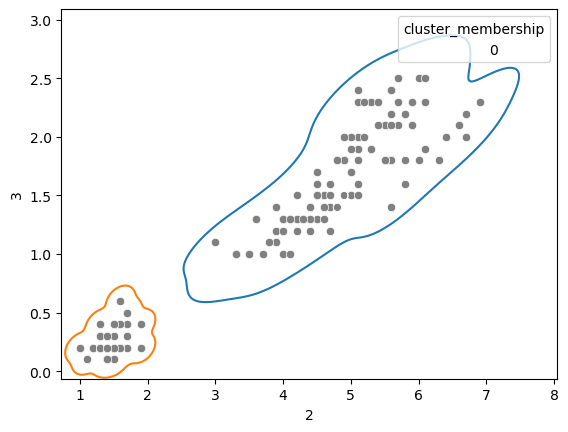

In [ ]:
cmap_membership = {1:'tab:blue', 2:'tab:orange', 3:'tab:green'}
sns.kdeplot(data=per_point_data,
            x=x,
            y=y,
            hue='cluster_membership',
            thresh=0.005,
            levels=1,
            #cmap='mako'
            )
sns.scatterplot(data=per_point_data, x=x, y=y, color='gray')
sns.scatterplot(data=per_point_data[(per_point_data[2] > 4.75) & (per_point_data[2] < 5) &\
                                    (per_point_data[3] > 1.2) & (per_point_data[3] < 1.7) ],
                x=x, y=y, hue='cluster_membership',palette=cmap_membership)



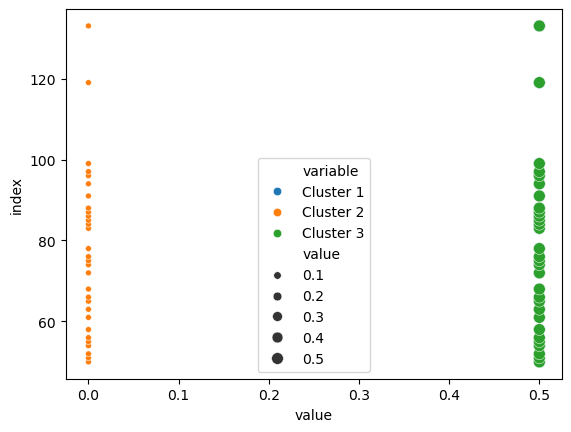

In [ ]:
fuzzymembership = per_point_data[(per_point_data[2] > 4) & (per_point_data[2] < 5.5) & (per_point_data[3] > 1.2) & (per_point_data[3] < 1.7) ]
fuzzymembership_melt = fuzzymembership[['Cluster 1', 'Cluster 2', 'Cluster 3','cluster_membership']].reset_index().melt(id_vars=['index','cluster_membership'])

sns.scatterplot(data=fuzzymembership_melt, x='value', y='index', hue='variable', palette='tab10', size='value')
plt.show()

In [36]:
per_point_data[(per_point_data[2] > 4.75) & (per_point_data[2] < 5) &
               (per_point_data[3] > 1.2) & (per_point_data[3] < 1.7) ]

,0,1,2,3,Cluster 1,Cluster 2,Cluster 3,cluster_membership
52,6.9,3.1,4.9,1.5,0.5,4.254806e-104,0.5,0
72,6.3,2.5,4.9,1.5,0.5,1.521399e-107,0.5,0
76,6.8,2.8,4.8,1.4,0.5,5.093945e-100,0.5,0


In [37]:
iris[(iris['petal_length'] > 4.75) & (iris['petal_length'] < 5) &\
     (iris['petal_width'] > 1.2) & (iris['petal_width'] < 1.7) ]

,sepal_length,sepal_width,petal_length,petal_width,species
52,6.9,3.1,4.9,1.5,versicolor
72,6.3,2.5,4.9,1.5,versicolor
76,6.8,2.8,4.8,1.4,versicolor


----

In [135]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import confusion_matrix

In [136]:
per_point_data_gmm = pd.DataFrame(X).join(pd.DataFrame(gmm.predict_proba(X), columns=['Cluster 1', 'Cluster 2', 'Cluster 3']))
per_point_data_gmm['cluster_membership'] = np.argmax(per_point_data_gmm.iloc[:,4:7],1)
per_point_data_annot = per_point_data_gmm.copy() 

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


In [137]:
per_point_data_annot = per_point_data_annot.join(iris['species'])
per_point_data_annot['cluster_membership_str'] = per_point_data_annot['cluster_membership'].apply(lambda x: 'Cluster ' + str(x+1))
per_point_data_annot.shape

(150, 10)

In [138]:
cross_tab = pd.crosstab(
    per_point_data_annot['species'],
    per_point_data_annot['cluster_membership_str']
)

cross_tab.rename_axis("Species", axis="rows", inplace=True)
cross_tab.rename_axis("Cluster", axis="columns", inplace=True)


cross_tab

Cluster,Cluster 1,Cluster 2,Cluster 3
Species,,,
setosa,0,50,0
versicolor,45,0,5
virginica,0,0,50


In [139]:
cluster_to_species = cross_tab.idxmax(axis=0)  # Map each cluster to the species with the highest count
print("Cluster-to-species mapping:\n", cluster_to_species)

Cluster-to-species mapping:
 Cluster
Cluster 1    versicolor
Cluster 2        setosa
Cluster 3     virginica
dtype: object


In [140]:
correct = 0
for cluster, species in cluster_to_species.items():
    correct += cross_tab.loc[species, cluster]

total = cross_tab.values.sum()
accuracy = correct / total

print(f"Clustering accuracy: {accuracy:.2f}")

Clustering accuracy: 0.97


In [141]:
from sklearn.metrics import roc_curve, roc_auc_score


In [142]:
cluster_to_species = dict(cluster_to_species)
species_to_cluster = {v:k for k,v in cluster_to_species.items()}

AUC for setosa: 1.00
AUC for versicolor: 1.00
AUC for virginica: 1.00


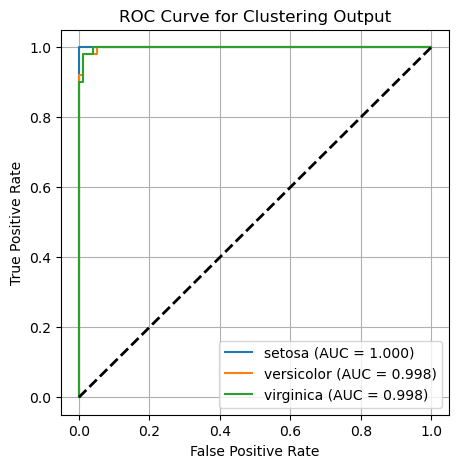

In [143]:
species_list = ['setosa', 'versicolor', 'virginica']
auc_scores = {}

plt.figure(figsize=(5, 5))


for species in species_list:
    y_true = (per_point_data_annot['species'] == species).astype(int)
    y_scores = per_point_data_annot[species_to_cluster[species]]

     # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)


    auc = roc_auc_score(y_true, y_scores)
    auc_scores[species] = auc
    print(f"AUC for {species}: {auc:.2f}")

    plt.plot(fpr, tpr, label=f'{species} (AUC = {auc:.3f})')


# Plot diagonal for random guess
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Clustering Output')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [144]:
probs_per_cluster_species = per_point_data_annot.iloc[:,[4,5,6,7,8]].reset_index().melt(id_vars=['index','cluster_membership','species']).sort_values('index')
probs_per_cluster_species.head()

,index,cluster_membership,species,variable,value
150,0,1,setosa,Cluster 2,1.000000e+00
300,0,1,setosa,Cluster 3,6.062163e-35
0,0,1,setosa,Cluster 1,1.011782e-43
1,1,1,setosa,Cluster 1,9.230082e-31
151,1,1,setosa,Cluster 2,1.000000e+00


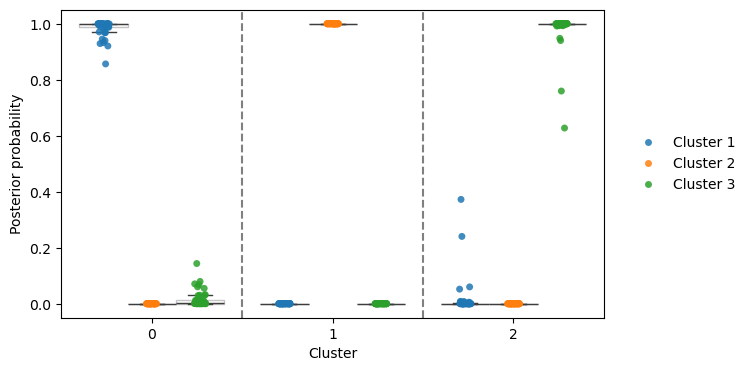

In [145]:
plt.figure(figsize=(7, 4))

ax = sns.stripplot(probs_per_cluster_species,
              x='cluster_membership',
              y='value',
              hue='variable',
              hue_order = ['Cluster 1', 'Cluster 2', 'Cluster 3'],
              dodge=True,
              alpha=0.85,)

sns.boxplot(probs_per_cluster_species,
              x='cluster_membership',
              y='value',
              hue='variable',
              hue_order = ['Cluster 1', 'Cluster 2', 'Cluster 3'],
              showfliers=False,
              boxprops=dict(alpha=.3,facecolor='white'),
              legend=False
              )

ax.set_xlabel('Cluster')
ax.set_ylabel('Posterior probability')

ax.axvline(0.5, color='gray', linestyle='--')
ax.axvline(1.5, color='gray', linestyle='--')
plt.legend(title='',bbox_to_anchor=(1.15, 0.5), loc='center',frameon=False)

plt.show()

------

## Check scoring manual vs GMM

In [155]:
### For all data points
px_class1 = [mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(x) for x in X] 
px_class2 = [mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(x) for x in X] 
px_class3 = [mvn(mean=mu3_hat, cov=Sigma3_hat).pdf(x) for x in X] 

px = np.column_stack([px_class1, px_class2, px_class3])
pi = np.array([pi1_hat, pi2_hat, pi3_hat])   

posteriors = calculate_posterior(px, pi)
posteriors_df = pd.DataFrame(posteriors, columns=['Cluster 1', 'Cluster 2', 'Cluster 3'])
per_point_data_manual = pd.DataFrame(X).join(posteriors_df)
per_point_data_manual['cluster_membership'] = np.argmax(per_point_data_manual.iloc[:,4:7],1)

In [156]:
per_point_data_manual = per_point_data_manual.join(iris['species'])
per_point_data_manual['cluster_membership_str'] = per_point_data_manual['cluster_membership'].apply(lambda x: 'Cluster ' + str(x+1))
per_point_data_manual.shape

(150, 10)

In [158]:
cross_tab = pd.crosstab(
    per_point_data_manual['species'],
    per_point_data_manual['cluster_membership_str']
)

cross_tab.rename_axis("Species", axis="rows", inplace=True)
cross_tab.rename_axis("Cluster", axis="columns", inplace=True)


cross_tab

Cluster,Cluster 1,Cluster 2,Cluster 3
Species,,,
setosa,0,0,50
versicolor,5,45,0
virginica,50,0,0


In [159]:
cluster_to_species = cross_tab.idxmax(axis=0)  # Map each cluster to the species with the highest count
print("Cluster-to-species mapping:\n", cluster_to_species)

Cluster-to-species mapping:
 Cluster
Cluster 1     virginica
Cluster 2    versicolor
Cluster 3        setosa
dtype: object


In [160]:
correct = 0
for cluster, species in cluster_to_species.items():
    correct += cross_tab.loc[species, cluster]

total = cross_tab.values.sum()
accuracy = correct / total

print(f"Clustering accuracy: {accuracy:.2f}")

Clustering accuracy: 0.97


In [161]:
cluster_to_species = dict(cluster_to_species)
species_to_cluster = {v:k for k,v in cluster_to_species.items()}

AUC for setosa: 1.00
AUC for versicolor: 1.00
AUC for virginica: 1.00


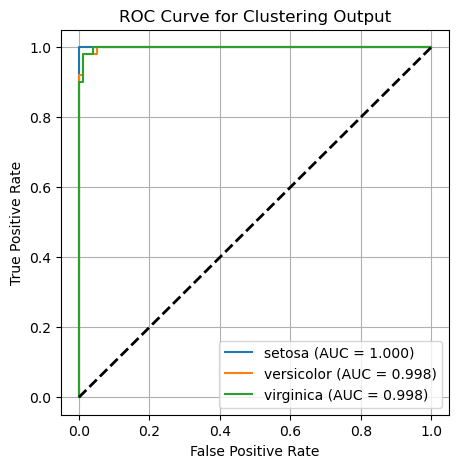

In [162]:
species_list = ['setosa', 'versicolor', 'virginica']
auc_scores = {}

plt.figure(figsize=(5, 5))


for species in species_list:
    y_true = (per_point_data_manual['species'] == species).astype(int)
    y_scores = per_point_data_manual[species_to_cluster[species]]

     # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)


    auc = roc_auc_score(y_true, y_scores)
    auc_scores[species] = auc
    print(f"AUC for {species}: {auc:.2f}")

    plt.plot(fpr, tpr, label=f'{species} (AUC = {auc:.3f})')


# Plot diagonal for random guess
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Clustering Output')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [163]:
probs_per_cluster_species = per_point_data_manual.iloc[:,[4,5,6,7,8]].reset_index().melt(id_vars=['index','cluster_membership','species']).sort_values('index')
probs_per_cluster_species.head()

,index,cluster_membership,species,variable,value
150,0,2,setosa,Cluster 2,8.876499e-45
300,0,2,setosa,Cluster 3,1.000000e+00
0,0,2,setosa,Cluster 1,2.460419e-34
1,1,2,setosa,Cluster 1,8.536458e-28
151,1,2,setosa,Cluster 2,1.645354e-31


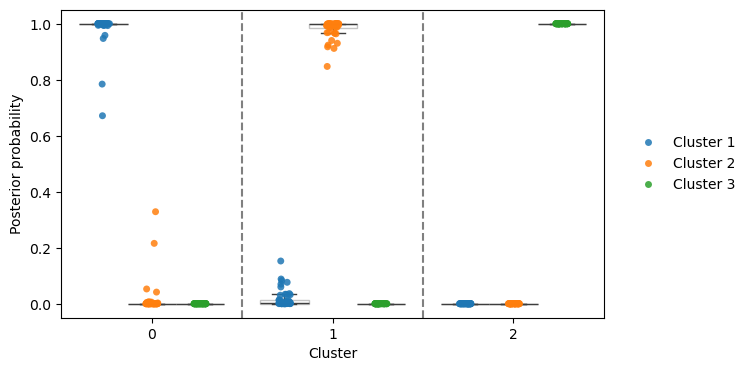

In [164]:
plt.figure(figsize=(7, 4))

ax = sns.stripplot(probs_per_cluster_species,
              x='cluster_membership',
              y='value',
              hue='variable',
              hue_order = ['Cluster 1', 'Cluster 2', 'Cluster 3'],
              dodge=True,
              alpha=0.85,)

sns.boxplot(probs_per_cluster_species,
              x='cluster_membership',
              y='value',
              hue='variable',
              hue_order = ['Cluster 1', 'Cluster 2', 'Cluster 3'],
              showfliers=False,
              boxprops=dict(alpha=.3,facecolor='white'),
              legend=False
              )

ax.set_xlabel('Cluster')
ax.set_ylabel('Posterior probability')

ax.axvline(0.5, color='gray', linestyle='--')
ax.axvline(1.5, color='gray', linestyle='--')
plt.legend(title='',bbox_to_anchor=(1.15, 0.5), loc='center',frameon=False)

plt.show()